In [ ]:
!pip install -q kagglehub

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "faresashraf1001/supermarket-sales"
)

print("Dataset tersimpan di:")
print(path)

Using Colab cache for faster access to the 'supermarket-sales' dataset.
Dataset tersimpan di:
/kaggle/input/supermarket-sales


In [ ]:
import os

print(os.listdir(path))

['SuperMarket Analysis.csv']


In [ ]:
import glob
import pandas as pd

csv_files = glob.glob(path + "/*.csv")

print(csv_files)

['/kaggle/input/supermarket-sales/SuperMarket Analysis.csv']


In [ ]:
df = pd.read_csv(csv_files[0])

In [ ]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 1000
Jumlah kolom: 17


In [ ]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [ ]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,float64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df["Date"].dtype

dtype('<M8[ns]')

In [ ]:
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%I:%M:%S %p"
)

In [ ]:
df["Time"].dtype

dtype('<M8[ns]')

In [ ]:
df["Year"] = df["Date"].dt.year

In [ ]:
df["Month"] = df["Date"].dt.month

In [ ]:
df["Day"] = df["Date"].dt.day

In [ ]:
df["Hour"] = df["Time"].dt.hour

In [ ]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Year,Month,Day,Hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,2019,1,5,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,2019,3,8,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,2019,3,3,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,2019,1,27,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2019,2,8,10


In [ ]:
def time_category(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

In [ ]:
df["Time Category"] = df["Hour"].apply(time_category)

In [ ]:
df[["Time", "Hour", "Time Category"]].head()

,Time,Hour,Time Category
0,1900-01-01 13:08:00,13,Afternoon
1,1900-01-01 10:29:00,10,Morning
2,1900-01-01 13:23:00,13,Afternoon
3,1900-01-01 20:33:00,20,Evening
4,1900-01-01 10:37:00,10,Morning


In [ ]:
df.shape

(1000, 22)

## 4. Key Performance Indicators

This section summarizes the main sales performance indicators, including total transactions, total sales, average transaction value, and total quantity sold.

In [ ]:
total_transactions = df["Invoice ID"].nunique()
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
total_quantity = df["Quantity"].sum()

print(f"Total Transactions : {total_transactions:,}")
print(f"Total Sales        : ${total_sales:,.2f}")
print(f"Average Sales      : ${average_sales:,.2f}")
print(f"Total Quantity     : {total_quantity:,}")

Total Transactions : 1,000
Total Sales        : $322,966.75
Average Sales      : $322.97
Total Quantity     : 5,510


**Cabang mana yang menghasilkan penjualan paling tinggi?**

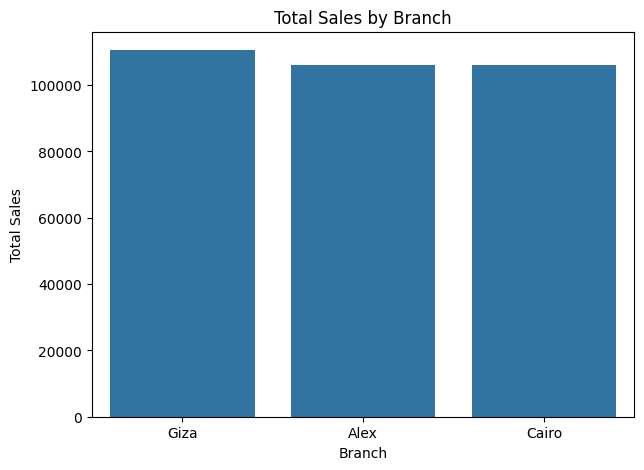

In [ ]:
branch_sales = (
    df.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

branch_sales
plt.figure(figsize=(7,5))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values
)

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
best_branch = branch_sales.idxmax()
best_branch_sales = branch_sales.max()

print("Best Branch:", best_branch)
print(f"Total Sales: ${best_branch_sales:,.2f}")

Best Branch: Giza
Total Sales: $110,568.71


Insight:

Branch Giza generated the highest total sales with approximately $110,568.71.

**Produk apa yang menghasilkan penjualan paling tinggi?**

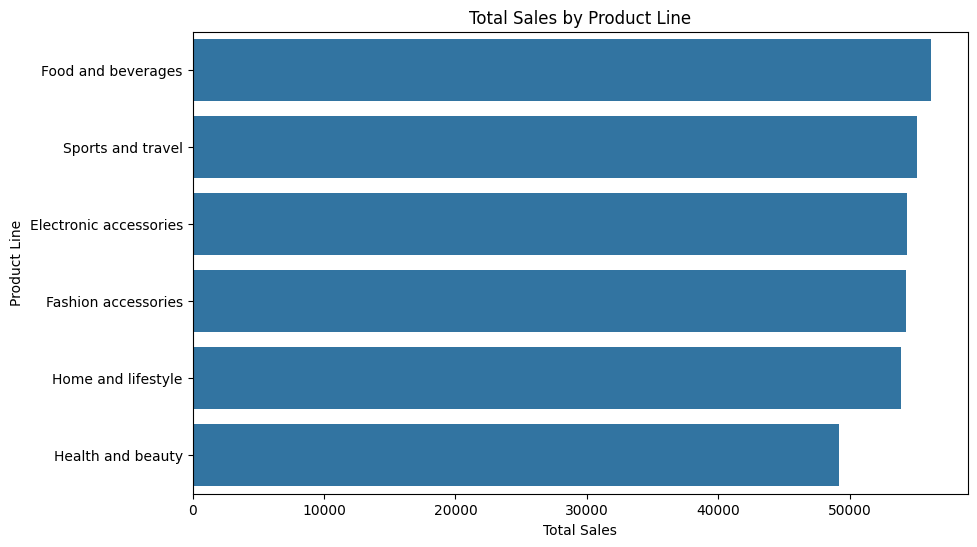

In [ ]:
product_sales = (
    df.groupby("Product line")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales
plt.figure(figsize=(10,6))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title("Total Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")

plt.show()

In [ ]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("Best Product Line:", best_product)
print(f"Total Sales: ${best_product_sales:,.2f}")

Best Product Line: Food and beverages
Total Sales: $56,144.84


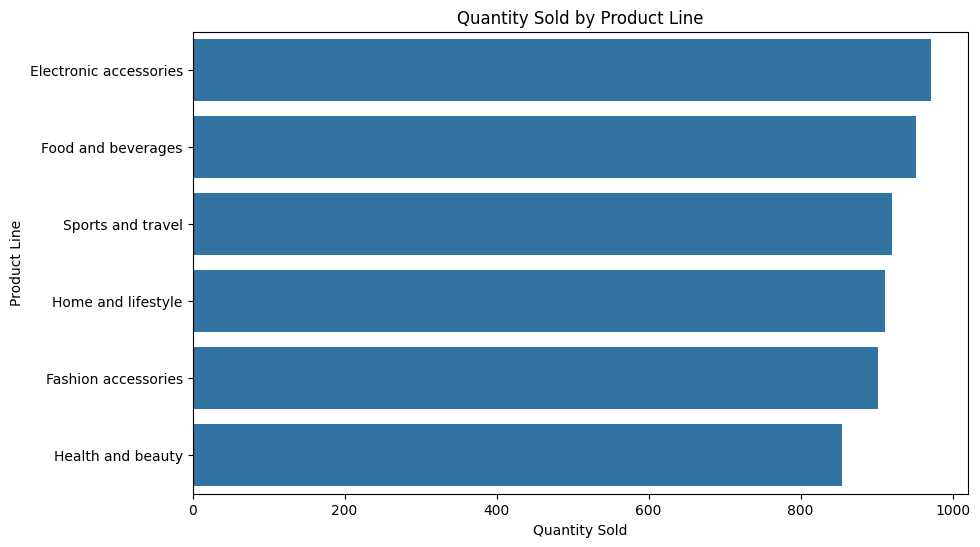

In [ ]:
product_quantity = (
    df.groupby("Product line")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity
plt.figure(figsize=(10,6))

sns.barplot(
    x=product_quantity.values,
    y=product_quantity.index
)

plt.title("Quantity Sold by Product Line")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Line")

plt.show()

**Tipe pelanggan mana yang menghasilkan sales lebih tinggi?**

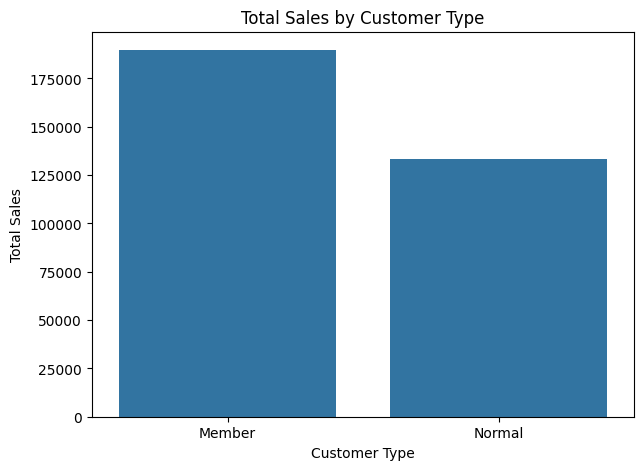

In [ ]:
customer_sales = (
    df.groupby("Customer type")["Sales"]
    .agg(["sum", "mean", "count"])
)

customer_sales
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Customer type",
    y="Sales",
    estimator="sum",
    errorbar=None
)

plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.show()

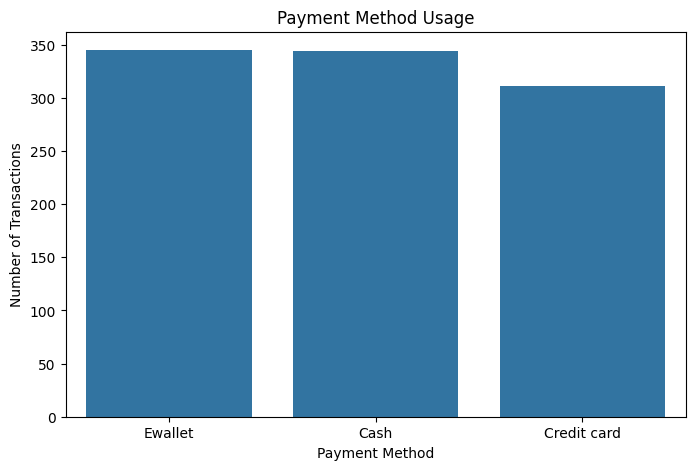

In [ ]:
payment_count = df["Payment"].value_counts()

payment_count
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_count.index,
    y=payment_count.values
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

**Jam berapa transaksi supermarket paling banyak terjadi?**

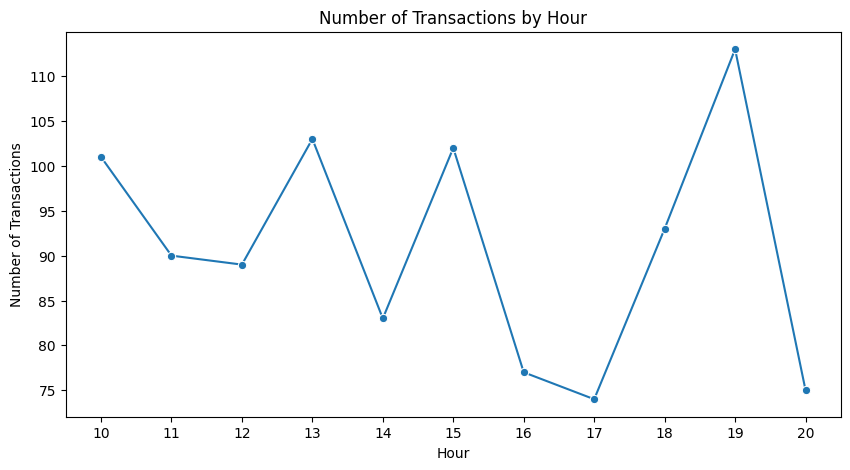

In [ ]:
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%I:%M:%S %p"
)

df["Hour"] = df["Time"].dt.hour
hourly_transactions = (
    df.groupby("Hour")["Invoice ID"]
    .nunique()
)

hourly_transactions
plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_transactions.index,
    y=hourly_transactions.values,
    marker="o"
)

plt.title("Number of Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.xticks(range(10, 21))

plt.show()

In [ ]:
busiest_hour = hourly_transactions.idxmax()
max_transactions = hourly_transactions.max()

print(f"Busiest Hour: {busiest_hour}:00")
print(f"Number of Transactions: {max_transactions}")

Busiest Hour: 19:00
Number of Transactions: 113


In [ ]:
payment_count = df["Payment"].value_counts()

print(payment_count)

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


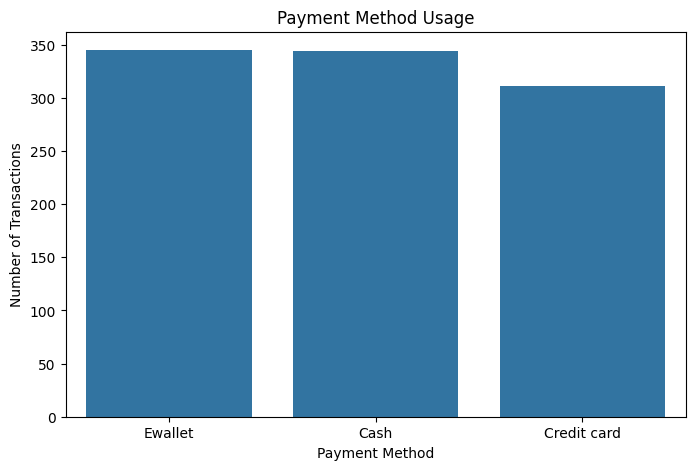

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_count.index,
    y=payment_count.values
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Sales, dtype: float64


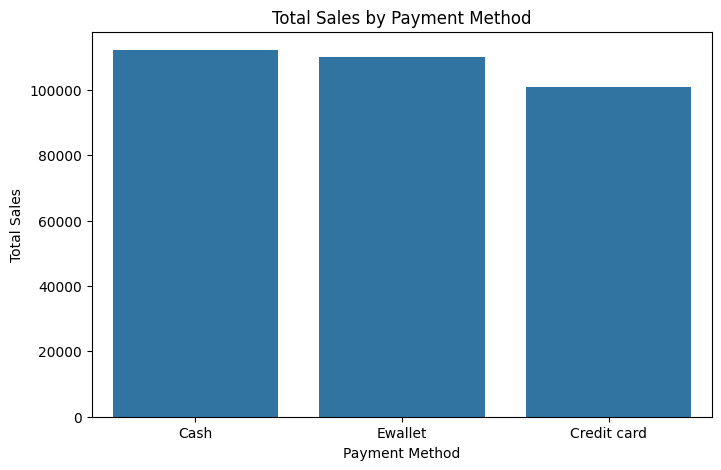

In [ ]:
payment_sales = (
    df.groupby("Payment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_sales)
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values
)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

plt.show()

Hour
19    39699.5130
13    34723.2270
10    31421.4810
15    31179.5085
14    30828.3990
11    30377.3295
12    26065.8825
18    26030.3400
16    25226.3235
17    24445.2180
20    22969.5270
Name: Sales, dtype: float64
Highest Sales Hour: 19:00
Total Sales: $39,699.51


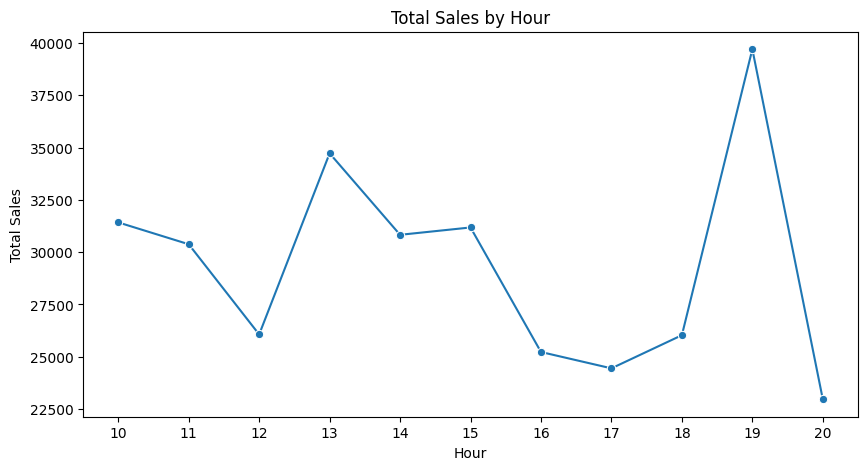

In [ ]:
hourly_sales = (
    df.groupby("Hour")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(hourly_sales)
best_sales_hour = hourly_sales.idxmax()
best_hour_sales = hourly_sales.max()

print(f"Highest Sales Hour: {best_sales_hour}:00")
print(f"Total Sales: ${best_hour_sales:,.2f}")
plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    marker="o"
)

plt.title("Total Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Sales")

plt.xticks(range(10, 21))

plt.show()

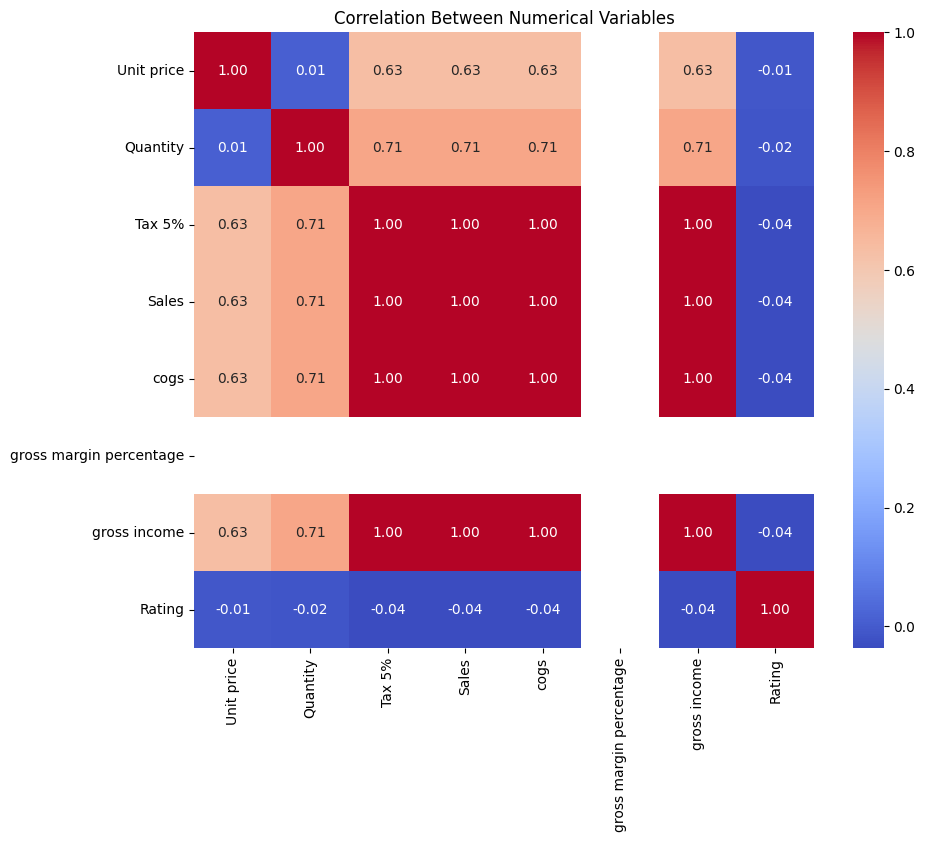

In [ ]:
numeric_columns = [
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Sales",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]

correlation = df[numeric_columns].corr()

correlation
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [ ]:
best_quantity_product = product_quantity.idxmax()
best_quantity = product_quantity.max()

print("Most Sold Product Line:", best_quantity_product)
print(f"Quantity Sold: {best_quantity:,}")

Most Sold Product Line: Electronic accessories
Quantity Sold: 971


In [ ]:
best_customer_type = (
    df.groupby("Customer type")["Sales"]
    .sum()
    .idxmax()
)

best_customer_sales = (
    df.groupby("Customer type")["Sales"]
    .sum()
    .max()
)

print("Highest Sales Customer Type:", best_customer_type)
print(f"Total Sales: ${best_customer_sales:,.2f}")

Highest Sales Customer Type: Member
Total Sales: $189,694.76


In [ ]:
most_used_payment = payment_count.idxmax()
most_used_payment_count = payment_count.max()

print("Most Used Payment:", most_used_payment)
print(f"Number of Transactions: {most_used_payment_count}")

Most Used Payment: Ewallet
Number of Transactions: 345


In [ ]:
# Ringkasan hasil analisis

print("===== SUPERMARKET SALES ANALYSIS =====")

print(f"\nTotal Transactions : {total_transactions:,}")
print(f"Total Sales        : ${total_sales:,.2f}")
print(f"Average Sales      : ${average_sales:,.2f}")
print(f"Total Quantity     : {total_quantity:,}")

print("\n===== BRANCH =====")
print(f"Best Branch        : {best_branch}")
print(f"Branch Sales       : ${best_branch_sales:,.2f}")

print("\n===== PRODUCT =====")
print(f"Best Product Line  : {best_product}")
print(f"Most Sold Product  : {best_quantity_product}")
print(f"Quantity Sold      : {best_quantity:,}")

print("\n===== CUSTOMER =====")
print(f"Top Customer Type  : {best_customer_type}")
print(f"Customer Sales     : ${best_customer_sales:,.2f}")

print("\n===== PAYMENT =====")
print(f"Most Used Payment  : {most_used_payment}")
print(f"Transactions      : {most_used_payment_count:,}")

print("\n===== TIME =====")
print(f"Busiest Hour       : {busiest_hour}:00")
print(f"Transactions       : {max_transactions:,}")
print(f"Highest Sales Hour : {best_sales_hour}:00")
print(f"Hourly Sales       : ${best_hour_sales:,.2f}")

===== SUPERMARKET SALES ANALYSIS =====

Total Transactions : 1,000
Total Sales        : $322,966.75
Average Sales      : $322.97
Total Quantity     : 5,510

===== BRANCH =====
Best Branch        : Giza
Branch Sales       : $110,568.71

===== PRODUCT =====
Best Product Line  : Food and beverages
Most Sold Product  : Electronic accessories
Quantity Sold      : 971

===== CUSTOMER =====
Top Customer Type  : Member
Customer Sales     : $189,694.76

===== PAYMENT =====
Most Used Payment  : Ewallet
Transactions      : 345

===== TIME =====
Busiest Hour       : 19:00
Transactions       : 113
Highest Sales Hour : 19:00
Hourly Sales       : $39,699.51


**Apakah customer Member juga memiliki rata-rata nilai transaksi yang lebih tinggi?**

In [ ]:
customer_analysis = (
    df.groupby("Customer type")["Sales"]
    .agg(
        total_sales="sum",
        average_sales="mean",
        transactions="count"
    )
    .sort_values("total_sales", ascending=False)
)

customer_analysis

,total_sales,average_sales,transactions
Customer type,,,
Member,189694.764,335.742945,565
Normal,133271.985,306.372379,435


In [ ]:
product_analysis = (
    df.groupby("Product line")
    .agg(
        total_sales=("Sales", "sum"),
        total_quantity=("Quantity", "sum"),
        average_sales=("Sales", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

product_analysis

,total_sales,total_quantity,average_sales
Product line,,,
Food and beverages,56144.8440,952,322.671517
Sports and travel,55122.8265,920,332.065220
Electronic accessories,54337.5315,971,319.632538
Fashion accessories,54305.8950,902,305.089298
Home and lifestyle,53861.9130,911,336.636956
Health and beauty,49193.7390,854,323.643020


In [ ]:
branch_analysis = (
    df.groupby("Branch")
    .agg(
        total_sales=("Sales", "sum"),
        total_quantity=("Quantity", "sum"),
        average_sales=("Sales", "mean"),
        transactions=("Invoice ID", "nunique")
    )
    .sort_values("total_sales", ascending=False)
)

branch_analysis

,total_sales,total_quantity,average_sales,transactions
Branch,,,,
Giza,110568.7065,1831,337.099715,328
Alex,106200.3705,1859,312.354031,340
Cairo,106197.6720,1820,319.872506,332


# Key Findings

Based on the exploratory data analysis, several key findings were identified.

### 1. Overall Sales Performance

The dataset contains 1,000 transactions with total sales of $322,966.75. The average transaction value was $322.97, with a total quantity of 5,510 products sold.

### 2. Branch Performance

Giza was the highest-performing branch based on total sales, generating approximately $110,568.71. Giza also recorded the highest average transaction value at approximately $337.10. However, Alex had more transactions and a higher total quantity sold, indicating that transaction volume did not necessarily result in the highest total sales.

### 3. Product Performance

Food and beverages generated the highest total sales at approximately $56,144.84. However, Electronic accessories recorded the highest quantity sold with 971 units. This indicates that the product line generating the highest sales was not necessarily the product line with the highest sales volume.

### 4. Customer Behavior

Member customers generated higher total sales than Normal customers, with $189,694.76 compared with $133,271.99. Members also had a higher average transaction value of $335.74 compared with $306.37 for Normal customers. This indicates that Member customers contributed more to overall sales and had a higher average transaction value.

### 5. Payment Method

E-wallet was the most frequently used payment method with 345 transactions, followed by Cash with 344 transactions and Credit card with 311 transactions. However, Cash generated the highest total sales among the three payment methods, with approximately $112,206.57.

### 6. Time-Based Sales Pattern

The highest number of transactions occurred at 19:00, with 113 transactions. The highest total sales were also recorded at 19:00, reaching approximately $39,699.51.

### 7. Correlation

Quantity showed a relatively strong positive correlation with Sales, with a correlation coefficient of approximately 0.71. This indicates that transactions involving larger quantities tend to be associated with higher sales values.

In contrast, Rating showed a very weak correlation with Sales, with a correlation coefficient of approximately -0.04. This suggests that customer ratings had little linear relationship with transaction sales in this dataset.

Several variables such as Sales, Tax 5%, COGS, and Gross Income also showed very strong correlations because they are mathematically related to transaction values.

# Conclusion

This project analyzed supermarket transaction data consisting of 1,000 transactions and 17 original variables. The analysis covered overall sales performance, branch performance, product performance, customer characteristics, payment methods, transaction time patterns, and relationships between numerical variables.

The results show that Giza was the highest-performing branch based on total sales, while Food and beverages generated the highest sales among product lines. Electronic accessories recorded the highest quantity sold, demonstrating that sales value and sales volume can produce different rankings.

Customer behavior also showed differences between Member and Normal customers. In terms of payment methods, Ewallet was the most frequently used based on transaction count, while Cash generated the highest total sales.

The time-based analysis showed that 19:00 was the busiest period, with 113 transactions and approximately $39,699.51 in sales. The correlation analysis also showed strong relationships among several transaction-related numerical variables, although some relationships are expected because the variables are mathematically derived from one another.

Overall, this analysis demonstrates how exploratory data analysis can be used to identify sales patterns and customer behavior that may support business decision-making related to product management, branch performance, customer engagement, and operational planning.